# Topological Analysis and Vulnerability Identification in Software Supply Chains

### Case Study: Flowise (AI Agent Orchestration Framework)

**Course:** Graph Algorithms | Dr. Avner Priel, 2026

**Team Members:** Ron Blanki , Moty Sakhartov, Idan Dahan


## Phase 1: Environment Initialization and Library Imports

In this section, we import the necessary libraries for data acquisition, graph processing, and mathematical visualization. We utilize `networkx` for constructing and analyzing the Directed Dependency Graph representing the dependency tree, and `matplotlib` combined with `pandas` for advanced data formatting and topological rendering.


In [1]:
import importlib.util
import subprocess
import sys


def install_if_missing(import_name: str, package_specification: str) -> None:

    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_specification]
        )


install_if_missing("powerlaw", "powerlaw==2.0.0")

install_if_missing("cvss", "cvss==3.6")

import requests
import urllib.parse
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import math
from cvss import CVSS3, CVSS4

# Optimizing for full-screen readability: lower DPI and smaller base size
plt.rcParams["figure.figsize"] = (5, 3.5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 8


## Phase 2: Data Ingestion and Graph Construction

To maintain a high degree of empirical accuracy, we extract the resolved transitive dependency graph directly from the Google Open Source Insights API (deps.dev). The target ecosystem is **Flowise version 3.1.2**, an open-source AI agent orchestration framework with a large transitive dependency ecosystem.

The data is parsed and loaded into a NetworkX `DiGraph` (Directed Graph), where nodes represent discrete software packages and directed edges denote a dependency requirement.

The dependency information is retrieved from the live deps.dev API. Consequently, the exact number of nodes, edges, resolved versions and detected communities may change as the upstream dependency metadata is updated. Each reported experiment is therefore associated with its retrieval date.

The topological analysis uses unique package names as graph nodes. When multiple resolved records share the same package name, they are aggregated into one node, while the corresponding versions are retained as node metadata.


In [2]:
from datetime import datetime, timezone


def fetch_and_build_graph(system: str, package_name: str, version: str) -> nx.DiGraph:

    print(f"Initializing data extraction for {package_name} (v{version})...")

    encoded_pkg = urllib.parse.quote(package_name, safe="")
    encoded_ver = urllib.parse.quote(version, safe="")

    url = (
        f"https://api.deps.dev/v3/systems/{system}/packages/"
        f"{encoded_pkg}/versions/{encoded_ver}:dependencies"
    )

    response = requests.get(url, timeout=60)
    response.raise_for_status()

    data = response.json()
    nodes_data = data.get("nodes", [])
    edges_data = data.get("edges", [])
    # Preserve every unique resolved package-version pair.
    resolved_version_keys = sorted(
        {
            (
                node["versionKey"]["system"],
                node["versionKey"]["name"],
                node["versionKey"]["version"],
            )
            for node in nodes_data
        }
    )
    graph = nx.DiGraph()

    # The graph is projected to unique package names.
    # Resolved versions are preserved as node metadata.
    for node in nodes_data:
        version_key = node["versionKey"]
        name = version_key["name"]
        resolved_version = version_key["version"]

        if name not in graph:
            graph.add_node(name, versions=set())

        graph.nodes[name]["versions"].add(resolved_version)

    for edge in edges_data:
        source_name = nodes_data[edge["fromNode"]]["versionKey"]["name"]
        target_name = nodes_data[edge["toNode"]]["versionKey"]["name"]

        graph.add_edge(source_name, target_name)

    # Convert sets to sorted lists for easier presentation.
    for node in graph.nodes:
        graph.nodes[node]["versions"] = sorted(graph.nodes[node]["versions"])

    graph.graph["fetched_at_utc"] = datetime.now(timezone.utc).isoformat()

    graph.graph["raw_node_records"] = len(nodes_data)
    graph.graph["raw_edge_records"] = len(edges_data)
    graph.graph["resolved_version_keys"] = [
        {"system": system, "name": package_name, "version": package_version}
        for system, package_name, package_version in resolved_version_keys
    ]

    print("\nData acquisition summary:")
    print(f"Fetched at UTC: {graph.graph['fetched_at_utc']}")
    print(f"Raw dependency-node records: {len(nodes_data)}")
    print(f"Unique package-name nodes: {graph.number_of_nodes()}")
    print(f"Raw dependency-edge records: {len(edges_data)}")
    print(f"Unique graph edges: {graph.number_of_edges()}")
    print(
        "Unique resolved package-version pairs:",
        len(graph.graph["resolved_version_keys"]),
    )

    return graph


target_system = "npm"
target_package = "flowise"
target_version = "3.1.2"

dependency_graph = fetch_and_build_graph(target_system, target_package, target_version)

print(
    "\nIs the package-level graph a DAG?",
    nx.is_directed_acyclic_graph(dependency_graph),
)


Initializing data extraction for flowise (v3.1.2)...

Data acquisition summary:
Fetched at UTC: 2026-07-27T14:28:32.843821+00:00
Raw dependency-node records: 3061
Unique package-name nodes: 2138
Raw dependency-edge records: 6645
Unique graph edges: 5016
Unique resolved package-version pairs: 2548

Is the package-level graph a DAG? False


### Generalizability of the Analysis Pipeline

Although Flowise is used as the case study, the core analysis pipeline is parameterized by the package ecosystem, package name and version.

By changing `target_system`, `target_package` and `target_version`, the pipeline can construct and analyze the resolved dependency graph of another package supported by deps.dev. Centrality analysis, community detection, random-network comparison, Small-World analysis, heavy-tail fitting, robustness simulation and exact-version advisory retrieval operate without application-specific changes.

Only local case-study selections, such as the package used for the Ego-Network and Jaccard analysis, may need to be adapted to the new system.


### Phase 2.1: Full Ecosystem Topology Visualization (The "Hairball")

To truly comprehend the risk landscape of modern software supply chains, we must first visualize the sheer complexity of the raw dependency graph.

In this phase, we render the entire Flowise ecosystem across all its nodes and edges. While the human eye cannot manually trace the individual dependency relationships in this raw "hairball," we apply a **Force-Directed layout** and a dynamic color map powered by the near-linear **Louvain method**. Based directly on the Community Detection results that will be fully analyzed in Phase 5, this visualizes how the chaotic web of dependencies naturally organizes into distinct structural clusters, setting the stage for our macro-level analysis.

Louvain is used in this phase only as a visualization aid for coloring the full network. The formal community analysis presented in Phase 5 uses directed Greedy Modularity Maximization.


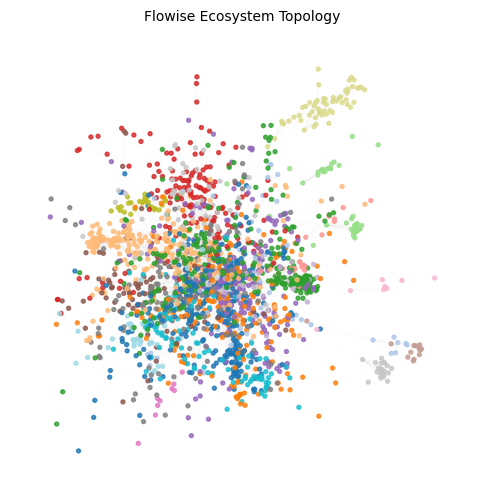

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import louvain_communities

if "dependency_graph" in globals():
    undirected_G = dependency_graph.to_undirected()
    visual_communities = list(louvain_communities(undirected_G, seed=42))
    visual_node_to_community = {
        node: i for i, community in enumerate(visual_communities) for node in community
    }

    # Reduced to 6x6 for better full-screen fit
    fig, ax = plt.subplots(figsize=(6, 6))
    pos = nx.spring_layout(undirected_G, k=0.22, seed=42)
    cmap = plt.colormaps.get_cmap("tab20")
    colors = [
        cmap((visual_node_to_community[n] % 20) / 20.0) for n in undirected_G.nodes()
    ]

    nx.draw_networkx_edges(undirected_G, pos, alpha=0.01, edge_color="gray", ax=ax)
    nx.draw_networkx_nodes(
        undirected_G, pos, node_color=colors, node_size=8, alpha=0.8, ax=ax
    )
    ax.set_title("Flowise Ecosystem Topology", fontsize=10)
    ax.axis("off")
    plt.show()
else:
    print("dependency_graph missing. Run Phase 2.")


## Phase 3: Topological Centrality Assessment (Betweenness Centrality)

A critical component of this audit is identifying "bridge" packages. These are utility libraries that may not have a high direct dependency count but serve as critical structural bridges connecting distinct developer communities within the graph.

We calculate the **Betweenness Centrality** for all vertices. A high score indicates a package that lies on the shortest path between many other packages. Packages with high Betweenness Centrality participate in a relatively large fraction of shortest dependency paths. Their removal or compromise may therefore have a disproportionate structural effect on connectivity between different parts of the network.


In [4]:
print(
    "Executing Betweenness Centrality algorithm. This may take a moment depending on graph density..."
)

# Calculate betweenness centrality

# Computational Complexity Analysis: Exact Betweenness Centrality calculation incurs a high
# time complexity cost of O(V * E) or O(V^3) for large networks. While a network of ~2,000 nodes
# is computationally feasible for exact calculations on modern hardware, massive real-world
# software ecosystems strictly require approximation techniques, such as limiting the 'k' parameter
# or scaling the analysis downward into targeted Ego-Networks.
centrality_scores = nx.betweenness_centrality(dependency_graph)

# Convert results to a structured Pandas DataFrame for analytical presentation
df_centrality = pd.DataFrame(
    list(centrality_scores.items()), columns=["Package Name", "Betweenness Centrality"]
)

# Sort the dataset to reveal the highest-risk single points of failure
df_centrality = df_centrality.sort_values(
    by="Betweenness Centrality", ascending=False
).reset_index(drop=True)

print("Top 10 Structural Bottlenecks Identified:")
display(df_centrality.head(10))


Executing Betweenness Centrality algorithm. This may take a moment depending on graph density...
Top 10 Structural Bottlenecks Identified:


,Package Name,Betweenness Centrality
0,yargs,0.000530
1,@grpc/proto-loader,0.000373
2,form-data,0.000256
3,@grpc/grpc-js,0.000255
4,readable-stream,0.000231
5,get-intrinsic,0.000230
6,read-pkg-up,0.000227
7,express,0.000222
8,@ladle/react,0.000199
9,read-pkg,0.000197


### Phase 3.1: Spectral Centrality Analysis (PageRank & HITS)

While Betweenness Centrality identifies structural bridges, open-source supply chains are inherently directional. To comprehensively map the threat landscape, we must also evaluate "structural authority" using spectral decomposition techniques.

We calculate **PageRank** and **HITS** (Hubs and Authorities) for the directed dependency graph. PageRank measures global structural prestige. HITS segregates nodes into *Authorities* (foundational libraries relied upon by many) and *Hubs* (orchestration layers that consolidate multiple packages). An Authority package represents a foundational dependency whose compromise may expose a large number of downstream dependents.


In [5]:
import networkx as nx
import pandas as pd

print("Executing Spectral Centrality Algorithms on Directed Graph...")

# 1. Compute PageRank (Alpha=0.85 is the standard damping factor)
pagerank_scores = nx.pagerank(dependency_graph, alpha=0.85)

# 2. Compute HITS (Max iterations set to 500 to ensure spectral convergence)
hubs_scores, auth_scores = nx.hits(dependency_graph, max_iter=500)

# 3. Compile results into a structured DataFrame
spectral_data = []
for node in dependency_graph.nodes():
    spectral_data.append(
        {
            "Package Name": node,
            "PageRank": round(pagerank_scores.get(node, 0), 6),
            "Authority Score (HITS)": round(auth_scores.get(node, 0), 6),
            "Hub Score (HITS)": round(hubs_scores.get(node, 0), 6),
        }
    )

df_spectral = pd.DataFrame(spectral_data)

print("Top 5 Structural Authorities (High In-Degree Structural Authorities):")
display(df_spectral.sort_values(by="Authority Score (HITS)", ascending=False).head(5))

print("Top 5 Operational Hubs " "(Packages Referencing Important Dependencies):")
display(df_spectral.sort_values(by="Hub Score (HITS)", ascending=False).head(5))


Executing Spectral Centrality Algorithms on Directed Graph...
Top 5 Structural Authorities (High In-Degree Structural Authorities):


,Package Name,PageRank,Authority Score (HITS),Hub Score (HITS)
97,tslib,0.022104,0.100114,-0.000000
93,@smithy/core,0.005831,0.069487,0.005957
96,@smithy/types,0.005875,0.063764,0.003639
92,@aws-sdk/types,0.001981,0.057671,0.005957
90,@aws-sdk/core,0.000953,0.041215,0.014813


Top 5 Operational Hubs (Packages Referencing Important Dependencies):


,Package Name,PageRank,Authority Score (HITS),Hub Score (HITS)
227,@aws-sdk/client-bedrock-runtime,0.000309,0.000133,0.030108
226,@aws-sdk/client-bedrock,0.000255,0.000060,0.029234
1173,@aws-sdk/nested-clients,0.000451,0.009509,0.028516
1643,@aws-sdk/client-sso,0.000281,0.001379,0.028255
513,@aws-sdk/credential-provider-http,0.000322,0.004162,0.015963


### Phase 3.2: Reverse-Dependency Reach Using Harmonic Centrality

In the graph representation used in this project, an edge `A → B` means that package A depends on package B.

NetworkX Harmonic Centrality measures how closely a node can be reached from other nodes. Therefore, a high score identifies a dependency that can be reached through short dependency paths from many packages. When impact is interpreted in the reverse direction — from a compromised dependency toward its dependents — this score represents high potential reverse-dependency reach.

The metric measures topological proximity, not actual propagation speed or infection probability.


In [6]:
print("Calculating Distance-Based Harmonic Centrality...")

# Compute Harmonic Centrality to handle potential disconnected nodes
harmonic_scores = nx.harmonic_centrality(dependency_graph)

# Format and rank the results
harmonic_data = [
    {"Package Name": node, "Harmonic Centrality": round(score, 2)}
    for node, score in harmonic_scores.items()
]
df_harmonic = (
    pd.DataFrame(harmonic_data)
    .sort_values(by="Harmonic Centrality", ascending=False)
    .reset_index(drop=True)
)

print("Top 5 Packages with the Highest " "Potential Reverse-Dependency Reach:")
display(df_harmonic.head(5))


Calculating Distance-Based Harmonic Centrality...
Top 5 Packages with the Highest Potential Reverse-Dependency Reach:


,Package Name,Harmonic Centrality
0,tslib,137.40
1,debug,103.18
2,ms,79.12
3,@babel/helper-plugin-utils,78.87
4,@smithy/core,74.83


### Phase 3.3: Centrality Algorithm Correlation Analysis

To understand if our different topological metrics identify the same risk vectors, we perform a **Spearman Correlation** analysis across the four centrality algorithms (Betweenness, PageRank, HITS Authority, and Harmonic).

A high correlation suggests structural agreement regarding package importance. Divergence indicates that distinct algorithms are capturing different topological threat models (e.g., global authority vs. local bridging capacity).


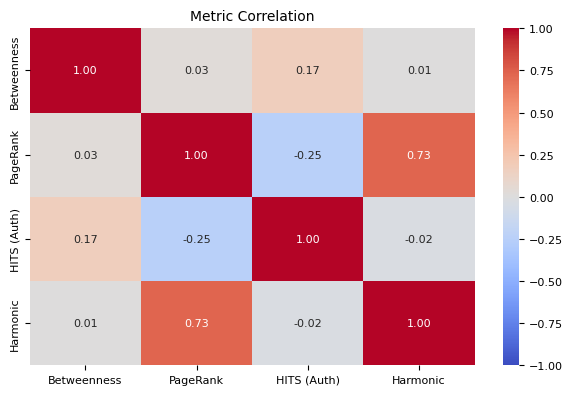

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if all(
    v in globals()
    for v in ["centrality_scores", "pagerank_scores", "auth_scores", "harmonic_scores"]
):
    nodes = list(dependency_graph.nodes())
    corr_data = {
        "Betweenness": [centrality_scores.get(n, 0) for n in nodes],
        "PageRank": [pagerank_scores.get(n, 0) for n in nodes],
        "HITS (Auth)": [auth_scores.get(n, 0) for n in nodes],
        "Harmonic": [harmonic_scores.get(n, 0) for n in nodes],
    }
    df_corr = pd.DataFrame(corr_data)
    correlation_matrix = df_corr.corr(method="spearman")

    # Reduced figsize for convenience
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        vmin=-1,
        vmax=1,
        center=0,
    )
    plt.title("Metric Correlation", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Centrality metrics missing.")


## Phase 4: Local Dependency Impact Visualization

To illustrate the local structural reach of a highly central package, we extract the two-hop reverse-dependency neighborhood of `form-data`.

The subgraph contains packages that depend directly or indirectly, within two dependency steps, on the reference package. It provides a local visualization of the package's structural neighborhood and complements the global centrality analysis.


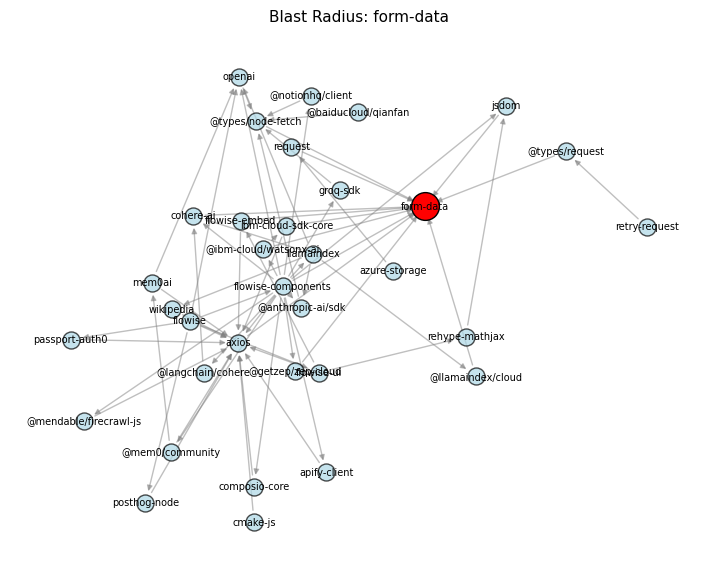

In [8]:
if "dependency_graph" in globals():
    primary_target = "form-data"
    impacted_nodes = set([primary_target])
    for neighbor in dependency_graph.predecessors(primary_target):
        impacted_nodes.add(neighbor)
        for second_layer_neighbor in dependency_graph.predecessors(neighbor):
            impacted_nodes.add(second_layer_neighbor)

    subgraph = dependency_graph.subgraph(impacted_nodes)
    pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)

    # Increased size for better detail visibility
    plt.figure(figsize=(9, 7))
    plt.title(f"Blast Radius: {primary_target}", fontsize=11)
    nx.draw_networkx_nodes(
        subgraph,
        pos,
        node_color="lightblue",
        node_size=150,
        edgecolors="black",
        alpha=0.7,
    )
    nx.draw_networkx_nodes(
        subgraph,
        pos,
        nodelist=[primary_target],
        node_color="red",
        node_size=400,
        edgecolors="black",
    )
    nx.draw_networkx_edges(
        subgraph, pos, arrowstyle="-|>", arrowsize=8, edge_color="gray", alpha=0.5
    )
    nx.draw_networkx_labels(subgraph, pos, font_size=7)
    plt.axis("off")
    plt.show()
else:
    print("dependency_graph not found.")


## Phase 5: Community Detection and Structural Segmentation

In complex directed graphs, nodes often aggregate into clusters or "communities" characterized by higher internal edge density compared to the rest of the network. In the context of a software supply chain, these communities represent structurally cohesive regions of the dependency graph.

We employ the Clauset-Newman-Moore greedy modularity maximization algorithm to partition the graph into structurally cohesive groups. The resulting communities allow us to examine whether highly central nodes and edges connect otherwise separated regions of the dependency ecosystem.

**Methodological Approach:** We apply the community-detection algorithm directly to the directed dependency graph. This preserves the direction of dependency relationships instead of first projecting the network into an undirected representation. The resulting partition is used consistently throughout the subsequent macro-structure and internal-community analyses.


In [9]:
from networkx.algorithms.community import greedy_modularity_communities
import pandas as pd

print("Analyzing community structure via Directed Modularity Optimization...")

# Execute community detection DIRECTLY on the directed graph (Removed to_undirected)
communities = sorted(
    list(greedy_modularity_communities(dependency_graph)), key=len, reverse=True
)

print(
    f"Detected {len(communities)} distinct "
    "structural communities within the ecosystem."
)

# Summarize community distribution with key components
community_stats = []
for i, comm in enumerate(communities):
    comm_nodes = list(comm)
    top_nodes = sorted(
        comm_nodes, key=lambda n: dependency_graph.in_degree(n), reverse=True
    )[:3]

    community_stats.append(
        {
            "Community_ID": i + 1,
            "Node_Count": len(comm),
            "Key_Components": ", ".join(top_nodes),
        }
    )

df_communities = (
    pd.DataFrame(community_stats)
    .sort_values(by="Node_Count", ascending=False)
    .reset_index(drop=True)
)

print("\nLargest Structural Communities (Top 5):")
display(df_communities.head(5))

# --- MAPPING PART 1: Top 10 Topological Bottlenecks ---
top_10_targets = df_centrality["Package Name"].head(10).tolist()
print("\n[PART 1] Mapping the Top 10 Topological Bottlenecks:")

for rank, target in enumerate(top_10_targets, start=1):
    for community_index, community in enumerate(communities, start=1):
        if target in community:
            print(f" - #{rank} '{target}' " f"is in Community #{community_index}")
            break


Analyzing community structure via Directed Modularity Optimization...
Detected 33 distinct structural communities within the ecosystem.

Largest Structural Communities (Top 5):


,Community_ID,Node_Count,Key_Components
0,1,474,"debug, uuid, zod"
1,2,152,"isobject, extend-shallow, define-property"
2,3,144,"semver, minipass, graceful-fs"
3,4,139,"@opentelemetry/core, @opentelemetry/instrument..."
4,5,138,"micromark-util-types, micromark-util-symbol, @..."



[PART 1] Mapping the Top 10 Topological Bottlenecks:
 - #1 'yargs' is in Community #9
 - #2 '@grpc/proto-loader' is in Community #4
 - #3 'form-data' is in Community #1
 - #4 '@grpc/grpc-js' is in Community #4
 - #5 'readable-stream' is in Community #10
 - #6 'get-intrinsic' is in Community #15
 - #7 'read-pkg-up' is in Community #18
 - #8 'express' is in Community #1
 - #9 '@ladle/react' is in Community #6
 - #10 'read-pkg' is in Community #18


### Phase 5.1: Ecosystem Architecture (Community Macro-Structure)

While the full topology demonstrates complexity, actionable cybersecurity intelligence requires abstraction.

In this phase, we collapse the raw network into a **Macro-Architecture Graph**. Each node represents one structural community identified by Greedy Modularity.
- **Node Size:** Proportional to the number of libraries residing within that community.
- **Edge Thickness:** Proportional to the volume of cross-community dependency links.
- **Color Coding:** Community #1 (the largest structural community) is highlighted in red, clearly illustrating its systemic dominance and structural gravity within the ecosystem.

The community partition is inherited directly from the directed Greedy Modularity analysis in Phase 5. For visualization, cross-community links are aggregated into an undirected macro-level representation.


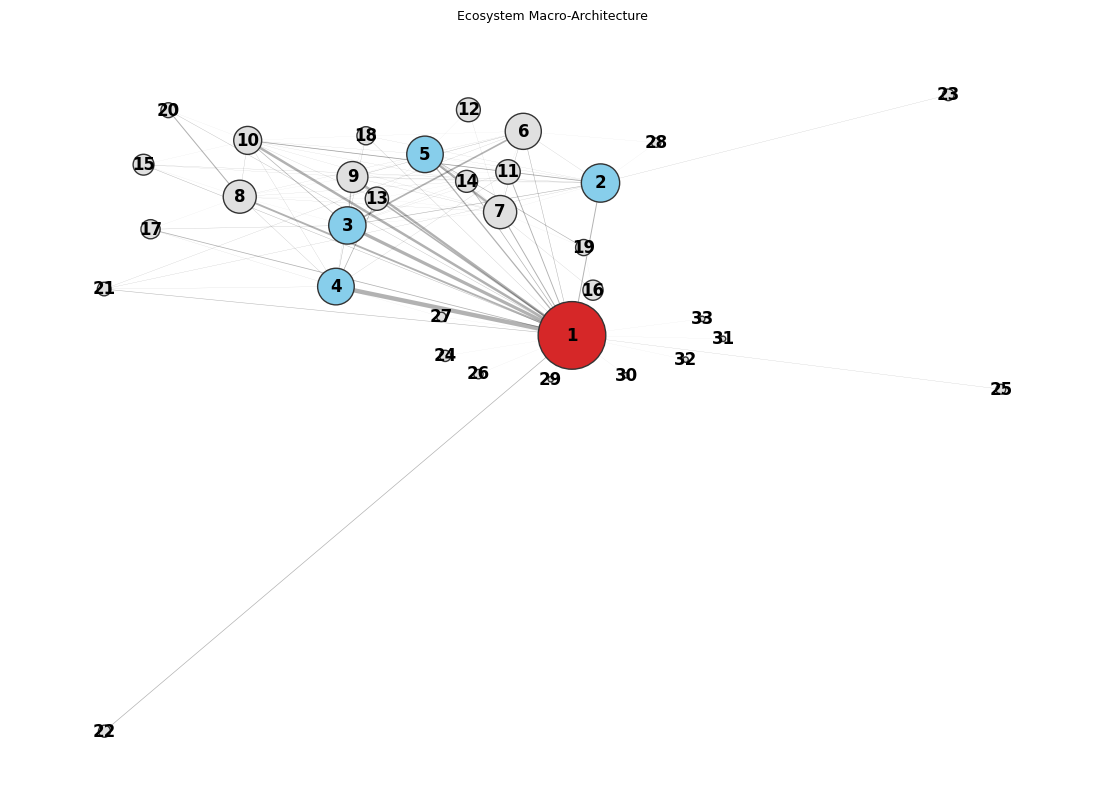

In [10]:
import matplotlib.pyplot as plt
import networkx as nx

if "dependency_graph" not in globals():
    raise RuntimeError("dependency_graph not found. Run Phase 2 first.")

if "communities" not in globals():
    raise RuntimeError("Community partition not found. Run Phase 5 first.")

# Used only to draw the macro graph as an undirected network.
undirected_G = dependency_graph.to_undirected()

# Reuse the Greedy Modularity communities calculated in Phase 5.
sorted_communities = sorted(communities, key=len, reverse=True)

plt.figure(figsize=(14, 10))

# Assign every package to its ranked community.
# The largest community receives rank 1.
node_to_ranked_comm = {
    node: rank + 1
    for rank, community in enumerate(sorted_communities)
    for node in community
}

# Create one macro-node for every community.
macro_graph = nx.Graph()

for rank, community in enumerate(sorted_communities, start=1):
    macro_graph.add_node(rank, size=len(community))

# Count dependency links that cross between communities.
for source, target in dependency_graph.edges():
    source_community = node_to_ranked_comm.get(source)
    target_community = node_to_ranked_comm.get(target)

    if (
        source_community is not None
        and target_community is not None
        and source_community != target_community
    ):
        if macro_graph.has_edge(source_community, target_community):
            macro_graph[source_community][target_community]["weight"] += 1
        else:
            macro_graph.add_edge(source_community, target_community, weight=1)

pos_macro = nx.kamada_kawai_layout(macro_graph)

node_sizes = [macro_graph.nodes[node]["size"] * 5 for node in macro_graph.nodes()]

node_colors = [
    "#d62728" if node == 1 else "#87CEEB" if node <= 5 else "#E0E0E0"
    for node in macro_graph.nodes()
]

edge_widths = [
    macro_graph[source][target]["weight"] * 0.05
    for source, target in macro_graph.edges()
]

nx.draw_networkx_nodes(
    macro_graph,
    pos_macro,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="#333333",
)

nx.draw_networkx_labels(macro_graph, pos_macro, font_size=12, font_weight="bold")

nx.draw_networkx_edges(macro_graph, pos_macro, width=edge_widths, alpha=0.3)

plt.title("Ecosystem Macro-Architecture", fontsize=9)

plt.axis("off")
plt.show()


### Phase 5.2: Global Edge Betweenness Analysis

Following the identification of the largest community identified by Greedy Modularity, we perform a global analysis of edge criticality.

Edge Betweenness is closely related to the principle used by Girvan–Newman. In this phase, however, it is calculated directly on the complete network to rank structural bridge edges. Network communities may be connected by a small number of critical dependency relationships that carry a disproportionate share of shortest-path connectivity between graph regions.


In [11]:
import networkx as nx
import pandas as pd

print(
    f"Performing Global Edge Betweenness Analysis (All {dependency_graph.number_of_nodes()} Nodes)..."
)

# Calculate Edge Betweenness Centrality for the ENTIRE DIRECTED graph
global_edge_betweenness = nx.edge_betweenness_centrality(dependency_graph)

# Sort the edges by their centrality score (highest first)
sorted_global_edges = sorted(
    global_edge_betweenness.items(), key=lambda item: item[1], reverse=True
)

# Format the results for the top 10 critical dependency links across the whole ecosystem
global_critical_edges_data = []
for edge, score in sorted_global_edges[:10]:
    global_critical_edges_data.append(
        {
            "Source Package": edge[0],
            "Target Dependency": edge[1],
            "Global Edge Betweenness Score": score,
        }
    )

df_global_critical_edges = pd.DataFrame(global_critical_edges_data)

print("\n Top 10 Highest Edge-Betweenness Links (Edges) in the ENTIRE Ecosystem:")
display(df_global_critical_edges)


Performing Global Edge Betweenness Analysis (All 2138 Nodes)...

 Top 10 Highest Edge-Betweenness Links (Edges) in the ENTIRE Ecosystem:


,Source Package,Target Dependency,Global Edge Betweenness Score
0,@grpc/proto-loader,yargs,0.000364
1,@grpc/grpc-js,@grpc/proto-loader,0.000272
2,yargs,read-pkg-up,0.000235
3,read-pkg-up,read-pkg,0.000204
4,flowise-embed-react,@ladle/react,0.000199
5,form-data,es-set-tostringtag,0.000172
6,yargs-parser,object.assign,0.000142
7,flowise,flowise-components,0.000140
8,es-set-tostringtag,get-intrinsic,0.000134
9,yargs,yargs-parser,0.000134


### Phase 5.3: Internal Edge Betweenness Assessment (Edge Betweenness Centrality)

Instead of applying a divisive community detection algorithm (like Girvan-Newman) inside an already structural community
 — which would force arbitrary structural fragmentation — we directly evaluate the internal dependency bottlenecks of Community #1.

We isolate the induced subgraph of Community #1 and calculate the **Edge Betweenness Centrality** for all its internal links. This metric identifies the precise dependency pairs that handle the highest volume of shortest paths within this localized neighborhood. These edges represent the strongest internal structural bottlenecks within the largest community.


In [12]:
import networkx as nx
import pandas as pd

print("Analyzing Internal Edge Betweenness " "within Community #1...")

# 1. Isolate the nodes belonging to Community #1 (index 0 of sorted_communities)
comm_1_nodes = sorted_communities[0]

# 2. Extract the induced subgraph from the primary directed ecosystem
comm_1_subgraph = dependency_graph.subgraph(comm_1_nodes)

# 3. Calculate internal Edge Betweenness Centrality
internal_edge_betweenness = nx.edge_betweenness_centrality(comm_1_subgraph)

# 4. Format, sort, and rank the top vulnerable linkages
internal_edge_data = [
    {
        "Source Package": u,
        "Target Dependency": v,
        "Internal Edge Betweenness": round(score, 6),
    }
    for (u, v), score in internal_edge_betweenness.items()
]

df_internal_edges = (
    pd.DataFrame(internal_edge_data)
    .sort_values(by="Internal Edge Betweenness", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 5 Highest Internal Edge-Betweenness " "Links inside Community #1:")
display(df_internal_edges.head(5))


Analyzing Internal Edge Betweenness within Community #1...

Top 5 Highest Internal Edge-Betweenness Links inside Community #1:


,Source Package,Target Dependency,Internal Edge Betweenness
0,flowise,flowise-components,0.001171
1,node-fetch,whatwg-url,0.000979
2,@modelcontextprotocol/sdk,express,0.000734
3,@langchain/openai,openai,0.000696
4,node-fetch,fetch-blob,0.000585


## Phase 5.4: Girvan–Newman Hierarchical Community Splitting

While Greedy Modularity provides a flat partition of the dependency graph, the Girvan–Newman algorithm reveals the hierarchical organization of the network by iteratively removing edges with the highest Edge Betweenness Centrality.

Due to the computational complexity of the algorithm, only the first hierarchical split is extracted. This provides a high-level view of the primary structural separation within the dependency network.

In parallel, Edge Betweenness Centrality is also computed inside the largest Greedy-Modularity community (Phase 5.3) in order to identify important internal bridge edges. Therefore, the two analyses serve complementary purposes: Girvan–Newman examines the global hierarchical structure of the network, whereas the internal Edge Betweenness analysis focuses on structural bottlenecks inside the largest community.


In [13]:
import networkx as nx

print("Executing First-Level Global " "Girvan-Newman Split...")

if "dependency_graph" not in globals():
    raise RuntimeError("Run the graph construction phase first.")

if "undirected_G" not in globals():
    undirected_G = dependency_graph.to_undirected()

# Exact signature of the graph currently being analyzed.
current_gn_signature = (
    frozenset(undirected_G.nodes()),
    frozenset(frozenset((source, target)) for source, target in undirected_G.edges()),
)

can_reuse_gn_result = (
    "gn_communities" in globals()
    and "_gn_graph_signature" in globals()
    and _gn_graph_signature == current_gn_signature
)

if can_reuse_gn_result:

    print("Reusing the previously calculated " "Girvan-Newman split.")

else:

    gn_generator = nx.community.girvan_newman(undirected_G)

    first_level_split = next(gn_generator)

    gn_communities = list(first_level_split)

    _gn_graph_signature = current_gn_signature

num_global_macro_clusters = len(gn_communities)

cluster_sizes = sorted([len(cluster) for cluster in gn_communities], reverse=True)

print(
    "Global network successfully bisected into "
    f"{num_global_macro_clusters} macro-clusters."
)

print("Macro-Cluster A Size: " f"{cluster_sizes[0]} packages")

print("Macro-Cluster B Size: " f"{cluster_sizes[1]} packages")

print("\nTopological Analysis Conclusion:")

print(
    "The first Girvan-Newman iteration divided the "
    "undirected dependency network into two structural "
    "groups containing "
    f"{cluster_sizes[0]} and {cluster_sizes[1]} packages."
)

print("This represents the algorithm's primary first-level " "hierarchical separation.")

print(
    "No functional meaning is assigned to the two groups "
    "without an additional package-content analysis."
)


Executing First-Level Global Girvan-Newman Split...
Global network successfully bisected into 2 macro-clusters.
Macro-Cluster A Size: 2079 packages
Macro-Cluster B Size: 59 packages

Topological Analysis Conclusion:
The first Girvan-Newman iteration divided the undirected dependency network into two structural groups containing 2079 and 59 packages.
This represents the algorithm's primary first-level hierarchical separation.
No functional meaning is assigned to the two groups without an additional package-content analysis.


## Phase 6: Global Structural Characterization

This phase characterizes the global structure of the dependency network using edge density, In-Degree statistics and the average clustering coefficient.

In-Degree measures how many packages directly depend on a given package and therefore identifies highly reused dependency hubs. Clustering is calculated on the undirected projection of the dependency graph so that it can be compared consistently with the Erdős–Rényi baseline used in Phase 6.2.

The purpose of this phase is to determine whether the network is uniformly sparse or whether its dependencies are concentrated around a small number of highly connected packages and densely connected local regions.


In [14]:
import networkx as nx
import numpy as np

print("Analyzing Global Structural Properties...")

number_of_nodes = dependency_graph.number_of_nodes()
number_of_edges = dependency_graph.number_of_edges()

edge_density = nx.density(dependency_graph)

in_degrees = np.asarray(
    [degree for _, degree in dependency_graph.in_degree()], dtype=float
)

average_in_degree = in_degrees.mean()
maximum_in_degree = in_degrees.max()

# Clustering is calculated consistently on the
# undirected structural projection.
structural_graph = dependency_graph.to_undirected()

average_clustering = nx.average_clustering(structural_graph)

print("\n--- Global Network Metrics ---")
print(f"Number of Nodes: {number_of_nodes}")
print(f"Number of Edges: {number_of_edges}")
print(f"Directed Edge Density: {edge_density:.6f}")
print(f"Average In-Degree: {average_in_degree:.6f}")
print(f"Maximum In-Degree: {maximum_in_degree:.0f}")
print(f"Average Undirected Clustering: {average_clustering:.6f}")

print("\nStructural Interpretation:")

print("The graph is globally sparse, but its dependencies " "are distributed unevenly.")

print(
    "A small number of packages have In-Degree values "
    "far above the network average, while the structural "
    "projection contains substantial local clustering."
)


Analyzing Global Structural Properties...

--- Global Network Metrics ---
Number of Nodes: 2138
Number of Edges: 5016
Directed Edge Density: 0.001098
Average In-Degree: 2.346118
Maximum In-Degree: 125
Average Undirected Clustering: 0.236507

Structural Interpretation:
The graph is globally sparse, but its dependencies are distributed unevenly.
A small number of packages have In-Degree values far above the network average, while the structural projection contains substantial local clustering.


### Phase 6.1: Heavy-Tailed Degree Distribution Analysis

Many technological networks exhibit heterogeneous degree distributions in which a small number of nodes accumulate substantially more connections than the majority of the network.

We examine the **In-Degree** distribution of the Flowise dependency network to determine whether it exhibits a heavy-tailed pattern and strong hub concentration. In this graph, high In-Degree represents a package depended upon by many other packages.

The log-log visualization is used as an initial descriptive view of the degree distribution. Formal statistical fitting and comparison with alternative tail distributions are performed in Phase 6.4.


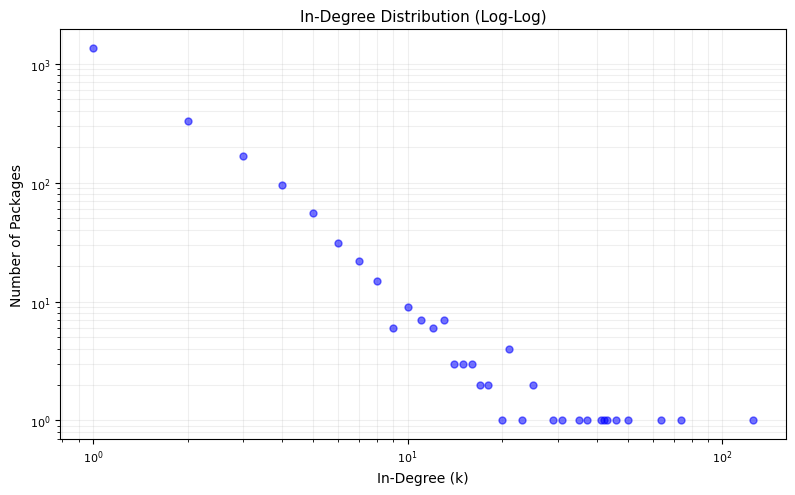

In [15]:
import numpy as np
import matplotlib.pyplot as plt

if "dependency_graph" in globals():
    in_degrees = [d for n, d in dependency_graph.in_degree()]
    degree_counts = np.bincount(in_degrees)
    degrees = np.arange(len(degree_counts))

    # Increased size for higher resolution
    plt.figure(figsize=(8, 5))
    valid = (degrees > 0) & (degree_counts > 0)
    plt.loglog(degrees[valid], degree_counts[valid], "bo", alpha=0.55, markersize=5)
    plt.title("In-Degree Distribution (Log-Log)", fontsize=11)
    plt.xlabel("In-Degree (k)", fontsize=10)
    plt.ylabel("Number of Packages", fontsize=10)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("dependency_graph not found.")


### Phase 6.2: Empirical Network vs. Erdős–Rényi Ensemble

To determine whether the structural properties of the Flowise dependency network can be explained by its size and density alone, we compare it against an ensemble of 50 directed Erdős–Rényi graphs.

Each random graph contains the same number of nodes and edges as the empirical dependency graph. We compare the networks using:

- Average In-Degree
- Maximum In-Degree
- Average Clustering Coefficient

Using multiple independent random graphs provides a more reliable baseline than relying on a single random realization. The experiment evaluates whether the hub concentration and clustering observed in the empirical network are consistently stronger than expected under random edge placement.


In [16]:
from scipy.sparse.csgraph import shortest_path

import numpy as np
import pandas as pd
import networkx as nx

# -------------------------------------------------------
# Phase 6.2:
# Empirical Network vs. Erdős–Rényi Ensemble
# -------------------------------------------------------


def largest_connected_subgraph(graph: nx.Graph) -> nx.Graph:
    """
    Return a view of the largest connected component.
    """
    if graph.number_of_nodes() == 0:
        raise ValueError("The graph is empty.")

    largest_component = max(nx.connected_components(graph), key=len)

    return graph.subgraph(largest_component)


def exact_average_shortest_path_length(graph: nx.Graph) -> float:
    """
    Calculate the exact average shortest-path length
    using SciPy's sparse graph implementation.
    """
    node_count = graph.number_of_nodes()

    if node_count <= 1:
        return 0.0

    adjacency_matrix = nx.to_scipy_sparse_array(
        graph, nodelist=list(graph.nodes()), dtype=np.float64, format="csr"
    )

    distance_matrix = shortest_path(
        adjacency_matrix, directed=False, unweighted=True, return_predecessors=False
    )

    return float(distance_matrix.sum() / (node_count * (node_count - 1)))


if "dependency_graph" not in globals():
    raise RuntimeError("Run the graph construction phase first.")


N_ER_RUNS = 50
RANDOM_SEED = 42

n_nodes = dependency_graph.number_of_nodes()
n_edges = dependency_graph.number_of_edges()

# -------------------------------------------------------
# Empirical graph metrics
# -------------------------------------------------------

empirical_in_degrees = np.asarray(
    [degree for _, degree in dependency_graph.in_degree()], dtype=float
)

empirical_average_in_degree = empirical_in_degrees.mean()

empirical_maximum_in_degree = empirical_in_degrees.max()

# Structural metrics are evaluated on the
# undirected projection.
empirical_undirected_graph = dependency_graph.to_undirected()

# Calculate node clustering only once.
empirical_node_clustering = nx.clustering(empirical_undirected_graph)

empirical_clustering = float(np.mean(list(empirical_node_clustering.values())))

empirical_lcc = largest_connected_subgraph(empirical_undirected_graph)

empirical_lcc_clustering = float(
    np.mean([empirical_node_clustering[node] for node in empirical_lcc.nodes()])
)

empirical_path_length = exact_average_shortest_path_length(empirical_lcc)

empirical_lcc_fraction = (
    empirical_lcc.number_of_nodes() / empirical_undirected_graph.number_of_nodes()
)

# -------------------------------------------------------
# Generate one Erdős–Rényi ensemble and calculate
# all metrics required by Phases 6.2 and 6.3.
# -------------------------------------------------------

er_average_in_degrees = []
er_maximum_in_degrees = []
er_clustering_values = []

# These arrays will be reused in Phase 6.3.
er_lcc_clustering_values = []
er_path_length_values = []
er_lcc_fraction_values = []

for run_index in range(N_ER_RUNS):

    er_graph = nx.gnm_random_graph(
        n=n_nodes, m=n_edges, seed=RANDOM_SEED + run_index, directed=True
    )

    er_in_degrees = np.asarray(
        [degree for _, degree in er_graph.in_degree()], dtype=float
    )

    er_average_in_degrees.append(er_in_degrees.mean())

    er_maximum_in_degrees.append(er_in_degrees.max())

    er_undirected_graph = er_graph.to_undirected()

    # Calculate clustering once for the complete graph.
    er_node_clustering = nx.clustering(er_undirected_graph)

    er_clustering_values.append(float(np.mean(list(er_node_clustering.values()))))

    er_lcc = largest_connected_subgraph(er_undirected_graph)

    # Reuse the already calculated node coefficients.
    er_lcc_clustering_values.append(
        float(np.mean([er_node_clustering[node] for node in er_lcc.nodes()]))
    )

    er_path_length_values.append(exact_average_shortest_path_length(er_lcc))

    er_lcc_fraction_values.append(
        er_lcc.number_of_nodes() / er_undirected_graph.number_of_nodes()
    )

# Convert once to NumPy arrays for consistent aggregation.
er_average_in_degrees = np.asarray(er_average_in_degrees, dtype=float)

er_maximum_in_degrees = np.asarray(er_maximum_in_degrees, dtype=float)

er_clustering_values = np.asarray(er_clustering_values, dtype=float)

er_lcc_clustering_values = np.asarray(er_lcc_clustering_values, dtype=float)

er_path_length_values = np.asarray(er_path_length_values, dtype=float)

er_lcc_fraction_values = np.asarray(er_lcc_fraction_values, dtype=float)

# -------------------------------------------------------
# Phase 6.2 summary table
# -------------------------------------------------------

er_results = pd.DataFrame(
    {
        "Metric": ["Average In-Degree", "Maximum In-Degree", "Average Clustering"],
        "Flowise": [
            empirical_average_in_degree,
            empirical_maximum_in_degree,
            empirical_clustering,
        ],
        f"ER Mean ({N_ER_RUNS} runs)": [
            er_average_in_degrees.mean(),
            er_maximum_in_degrees.mean(),
            er_clustering_values.mean(),
        ],
        "ER Standard Deviation": [
            er_average_in_degrees.std(ddof=1),
            er_maximum_in_degrees.std(ddof=1),
            er_clustering_values.std(ddof=1),
        ],
    }
)

display(er_results.round(6))

# -------------------------------------------------------
# Empirical one-sided probabilities
# -------------------------------------------------------

maximum_degree_p_value = (
    1 + np.sum(er_maximum_in_degrees >= empirical_maximum_in_degree)
) / (N_ER_RUNS + 1)

clustering_p_value = (1 + np.sum(er_clustering_values >= empirical_clustering)) / (
    N_ER_RUNS + 1
)

print(
    "\nEmpirical probability that an ER graph has "
    "an equal or larger maximum In-Degree:"
)

print(f"p = {maximum_degree_p_value:.4f}")

print(
    "\nEmpirical probability that an ER graph has "
    "an equal or larger clustering coefficient:"
)

print(f"p = {clustering_p_value:.4f}")

# -------------------------------------------------------
# Interpretation
# -------------------------------------------------------

print("\nStructural Interpretation:")

print(
    "The empirical graph is compared against an ensemble "
    f"of {N_ER_RUNS} Erdős–Rényi graphs with the same "
    "number of nodes and edges."
)

print(
    "The comparison evaluates whether the observed hub "
    "concentration and clustering are consistently stronger "
    "than expected under random edge placement."
)

print(
    "The same random-graph ensemble is retained for "
    "the Small-World analysis in Phase 6.3."
)


ValueError: Buffer dtype mismatch, expected 'const int' but got 'long long'

### Phase 6.3: Quantitative Small-World Analysis

A Small-World network combines two structural properties:

1. A clustering coefficient substantially higher than that of a comparable random network.
2. An average shortest-path length that remains close to the random-network baseline.

The analysis is performed on the largest connected component of the undirected structural projection, because average shortest-path length is defined for connected graphs.

We compare the empirical network with 50 Erdős–Rényi graphs containing the same number of nodes and edges. The comparison is summarized using:

- The clustering ratio: $\frac{C}{C_r}$
- The path-length ratio: $\frac{L}{L_r}$
- The Small-World coefficient:

$$\sigma = \frac{\frac{C}{C_r}}{\frac{L}{L_r}}$$

A value of $\sigma > 1$, together with a path-length ratio close to 1, provides quantitative evidence of Small-World structure.


In [ ]:
# -------------------------------------------------------
# Phase 6.3:
# Small-World Analysis
# -------------------------------------------------------

import numpy as np
import pandas as pd

# -------------------------------------------------------
# Verify that Phase 6.2 was executed
# -------------------------------------------------------

required_phase_62_variables = [
    "N_ER_RUNS",
    "empirical_lcc_clustering",
    "empirical_path_length",
    "empirical_lcc_fraction",
    "er_lcc_clustering_values",
    "er_path_length_values",
    "er_lcc_fraction_values",
]

missing_variables = [
    variable_name
    for variable_name in required_phase_62_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run Phase 6.2 before Phase 6.3. "
        "Missing variables: " + ", ".join(missing_variables)
    )


# -------------------------------------------------------
# Reuse the empirical metrics calculated in Phase 6.2
# -------------------------------------------------------

empirical_sw_clustering = empirical_lcc_clustering


# -------------------------------------------------------
# Reuse the Erdős–Rényi ensemble from Phase 6.2
# -------------------------------------------------------

random_clustering_values = np.asarray(er_lcc_clustering_values, dtype=float)

random_path_length_values = np.asarray(er_path_length_values, dtype=float)

random_lcc_fractions = np.asarray(er_lcc_fraction_values, dtype=float)

mean_random_clustering = random_clustering_values.mean()

mean_random_path_length = random_path_length_values.mean()


# -------------------------------------------------------
# Small-world ratios
# -------------------------------------------------------

clustering_ratio = empirical_sw_clustering / mean_random_clustering

path_length_ratio = empirical_path_length / mean_random_path_length

small_world_sigma = clustering_ratio / path_length_ratio


# -------------------------------------------------------
# Summary table
# -------------------------------------------------------

small_world_results = pd.DataFrame(
    [
        {
            "Network": "Flowise",
            "Average Clustering": empirical_sw_clustering,
            "Average Path Length": empirical_path_length,
            "LCC Fraction": empirical_lcc_fraction,
        },
        {
            "Network": f"ER Mean ({N_ER_RUNS} runs)",
            "Average Clustering": mean_random_clustering,
            "Average Path Length": mean_random_path_length,
            "LCC Fraction": random_lcc_fractions.mean(),
        },
    ]
)

display(small_world_results.round(6))


# -------------------------------------------------------
# Results
# -------------------------------------------------------

print("\nClustering ratio C / Cr:", round(clustering_ratio, 4))

print("Path-length ratio L / Lr:", round(path_length_ratio, 4))

print("Small-world coefficient sigma:", round(small_world_sigma, 4))


# -------------------------------------------------------
# Interpretation
# -------------------------------------------------------

print("\nInterpretation:")

if small_world_sigma > 1 and path_length_ratio <= 1.5:
    print(
        "The network exhibits small-world "
        "characteristics: clustering is substantially "
        "higher than the random baseline while path "
        "length remains of a comparable order."
    )
else:
    print(
        "The current results do not provide clear " "evidence of small-world structure."
    )


,Network,Average Clustering,Average Path Length,LCC Fraction
0,Flowise,0.236456,5.178593,1.000000
1,ER Mean (50 runs),0.002278,5.133069,0.990977



Clustering ratio C / Cr: 103.8125
Path-length ratio L / Lr: 1.0089
Small-world coefficient sigma: 102.8999

Interpretation:
The network exhibits small-world characteristics: clustering is substantially higher than the random baseline while path length remains of a comparable order.


### Phase 6.4: Statistical Heavy-Tail and Power-Law Analysis

The log-log degree plot in Phase 6.1 provides an initial visual indication of a long-tailed In-Degree distribution. In this phase, we evaluate the tail statistically.

A discrete Maximum-Likelihood fit is applied to all positive In-Degree observations. The fitted Power-Law model is then compared with two alternative distributions:

- Lognormal
- Exponential

The log-likelihood ratio \(R\) indicates which model is preferred:

- \(R>0\): the Power-Law model is preferred.
- \(R<0\): the alternative model is preferred.

The corresponding \(p\)-value indicates whether the difference between the two candidate models is statistically meaningful.


Number of positive In-Degree observations: 2149
Estimated alpha: 2.6091
Estimated xmin: 4.0
Observations in fitted tail: 287


,Comparison,Log-Likelihood Ratio R,p-value
0,Power Law vs. Lognormal,-0.028886,0.563750
1,Power Law vs. Exponential,66.555519,0.000531


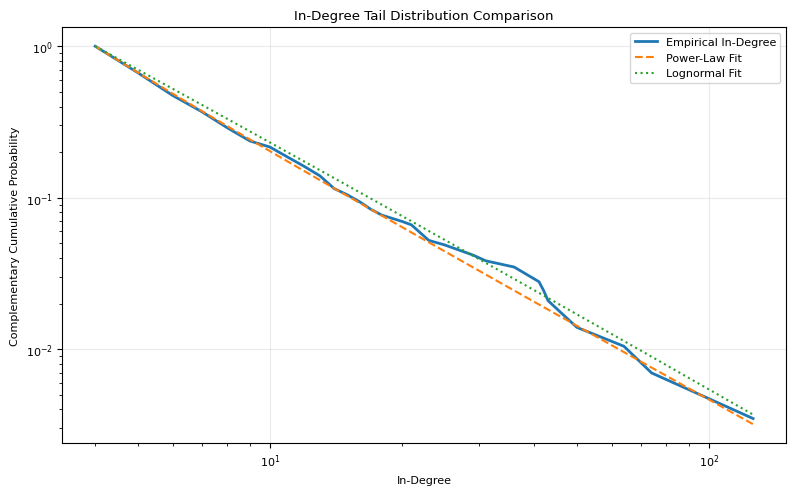


Interpretation:
The comparison between Power Law and Lognormal is inconclusive.
Power Law is statistically preferred over Exponential.


In [ ]:
# -------------------------------------------------------
# Phase 6.4:
# Statistical Heavy-Tail / Power-Law Analysis
# -------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw

positive_in_degrees = np.asarray(
    [degree for _, degree in dependency_graph.in_degree() if degree > 0], dtype=int
)

print("Number of positive In-Degree observations:", len(positive_in_degrees))

fit = powerlaw.Fit(positive_in_degrees, discrete=True, verbose=False)

estimated_alpha = fit.power_law.alpha
estimated_xmin = fit.power_law.xmin

tail_observation_count = int(np.sum(positive_in_degrees >= estimated_xmin))

powerlaw_vs_lognormal_R, powerlaw_vs_lognormal_p = fit.distribution_compare(
    "power_law", "lognormal"
)

powerlaw_vs_exponential_R, powerlaw_vs_exponential_p = fit.distribution_compare(
    "power_law", "exponential"
)

powerlaw_results = pd.DataFrame(
    [
        {
            "Comparison": "Power Law vs. Lognormal",
            "Log-Likelihood Ratio R": powerlaw_vs_lognormal_R,
            "p-value": powerlaw_vs_lognormal_p,
        },
        {
            "Comparison": "Power Law vs. Exponential",
            "Log-Likelihood Ratio R": powerlaw_vs_exponential_R,
            "p-value": powerlaw_vs_exponential_p,
        },
    ]
)

print(f"Estimated alpha: " f"{estimated_alpha:.4f}")

print(f"Estimated xmin: " f"{estimated_xmin}")

print(f"Observations in fitted tail: " f"{tail_observation_count}")

display(powerlaw_results.round(6))

# -------------------------------------------------------
# CCDF visualization
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

fit.plot_ccdf(ax=ax, linewidth=2, label="Empirical In-Degree")

fit.power_law.plot_ccdf(ax=ax, linestyle="--", label="Power-Law Fit")

fit.lognormal.plot_ccdf(ax=ax, linestyle=":", label="Lognormal Fit")

ax.set_xlabel("In-Degree")
ax.set_ylabel("Complementary Cumulative Probability")
ax.set_title("In-Degree Tail Distribution Comparison")

ax.grid(alpha=0.25)

ax.legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Interpretation
# -------------------------------------------------------

print("\nInterpretation:")


def interpret_distribution_comparison(
    alternative_name: str, likelihood_ratio: float, p_value: float
) -> None:

    if p_value < 0.05:
        if likelihood_ratio > 0:
            print(f"Power Law is statistically preferred " f"over {alternative_name}.")
        else:
            print(f"{alternative_name} is statistically " "preferred over Power Law.")
    else:
        print(
            f"The comparison between Power Law and "
            f"{alternative_name} is inconclusive."
        )


interpret_distribution_comparison(
    "Lognormal", powerlaw_vs_lognormal_R, powerlaw_vs_lognormal_p
)

interpret_distribution_comparison(
    "Exponential", powerlaw_vs_exponential_R, powerlaw_vs_exponential_p
)


### Phase 6.4 — Conclusion: Heavy-Tailed but Not Uniquely Power-Law

The fitted tail contained 287 observations, beginning at an estimated minimum In-Degree of \(x_{\min}=4\). The estimated Power-Law exponent was:

\[
\alpha = 2.6091
\]

The Power-Law model was strongly preferred over the Exponential alternative:

\[
R=66.5555,\qquad p=0.000531
\]

For the fitted tail, the Power-Law model provides a significantly better fit than the Exponential alternative.

The comparison between Power Law and Lognormal was not statistically decisive:

\[
R=-0.0289,\qquad p=0.563750
\]

Therefore, the network is best characterized as having a heavy-tailed In-Degree distribution with strong hub concentration. The evidence supports Power Law over Exponential, while Power Law and Lognormal remain statistically comparable descriptions of the tail.


### Phase 6 — Conclusion: Non-Random, Small-World and Heavy-Tailed Structure

The global structural experiments reveal three complementary properties of the Flowise dependency network.

First, comparison with 50 Erdős–Rényi graphs showed that the empirical network contains substantially stronger hubs and clustering than expected under random edge placement. Its maximum In-Degree was 126, compared with a random mean of 9.24, and its clustering coefficient was 0.236456, compared with a random mean of 0.002257.

Second, the network exhibited strong Small-World characteristics. Its clustering was more than 103 times higher than the random baseline, while its average shortest-path length differed by less than 1%. The resulting Small-World coefficient was 102.8999.

Third, statistical tail fitting showed that the In-Degree distribution is heavy-tailed. A Power-Law model was significantly preferred over an Exponential model, although it could not be distinguished statistically from a Lognormal alternative.

Together, these results describe a structurally organized ecosystem that combines dense local dependency regions, short global paths and a small number of exceptionally important dependency hubs.


## Phase 7: Robustness Analysis — Static Targeted Attack vs. Random Failure

To evaluate the structural resilience of the dependency network, we compare two node-removal strategies.

1. **Static Targeted Attack:** Betweenness Centrality is calculated once on the original graph. The 50 highest-ranked packages are then removed according to this fixed ranking.
2. **Random Failure Baseline:** Fifty packages are selected uniformly at random. To avoid drawing conclusions from a single random sample, this experiment is repeated 100 times.

Network degradation is measured using the size of the Largest Weakly Connected Component (LWCC). The random baseline is presented using its mean curve and a 95% confidence interval.


,Strategy,Nodes Removed,Graph Nodes Removed (%),Final LWCC Reduction (%),Standard Deviation
0,Static Targeted Betweenness Attack,50,2.3256,8.8837,NaN
1,Random Failure (100 runs),50,2.3256,3.0363,0.32



Empirical probability that random removal is at least as destructive as the targeted attack:
p = 0.0099


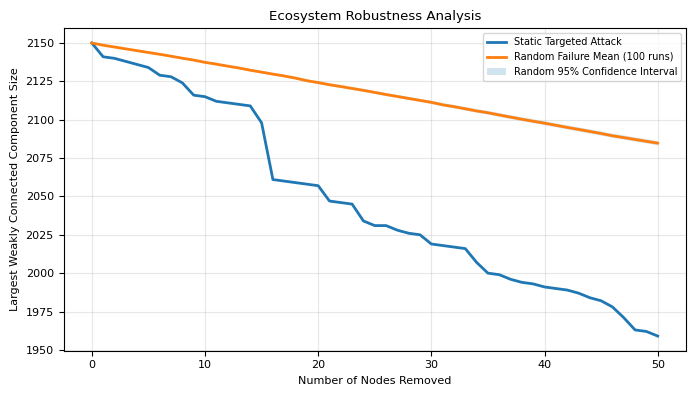

In [ ]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd


def calculate_removal_curve(
    original_graph: nx.Graph, removal_sequence: list
) -> np.ndarray:
    """
    Calculate the exact largest-component size after every
    node removal using reverse insertion and Union-Find.

    The returned values are identical to repeatedly removing
    nodes and recalculating connected components.
    """

    removal_sequence = list(removal_sequence)

    if len(removal_sequence) != len(set(removal_sequence)):
        raise ValueError("The removal sequence must contain unique nodes.")

    removed_nodes = set(removal_sequence)

    active_nodes = set(original_graph.nodes()) - removed_nodes

    parent = {}
    component_size = {}
    maximum_component_size = 0

    def add_node(node) -> None:
        nonlocal maximum_component_size

        parent[node] = node
        component_size[node] = 1

        maximum_component_size = max(maximum_component_size, 1)

    def find(node):
        while parent[node] != node:
            parent[node] = parent[parent[node]]
            node = parent[node]

        return node

    def union(first_node, second_node) -> None:
        nonlocal maximum_component_size

        first_root = find(first_node)
        second_root = find(second_node)

        if first_root == second_root:
            return

        if component_size[first_root] < component_size[second_root]:
            first_root, second_root = (second_root, first_root)

        parent[second_root] = first_root

        component_size[first_root] += component_size[second_root]

        maximum_component_size = max(maximum_component_size, component_size[first_root])

    # Build the graph state after all requested removals.
    for node in active_nodes:
        add_node(node)

    for source, target in original_graph.edges():
        if source in active_nodes and target in active_nodes:
            union(source, target)

    history = np.empty(len(removal_sequence) + 1, dtype=float)

    # State after every node in the sequence was removed.
    history[-1] = maximum_component_size

    # Add removed nodes back in reverse order.
    for index in range(len(removal_sequence) - 1, -1, -1):
        node = removal_sequence[index]

        add_node(node)
        active_nodes.add(node)

        for neighbor in original_graph.neighbors(node):
            if neighbor in active_nodes:
                union(node, neighbor)

        history[index] = maximum_component_size

    return history


if "dependency_graph" not in globals():
    raise RuntimeError("Run the graph construction phase first.")

# Weak connectivity in a directed graph is equivalent to
# ordinary connectivity in its undirected projection.
robustness_graph = dependency_graph.to_undirected()

if "df_centrality" not in globals():
    centrality_scores = nx.betweenness_centrality(dependency_graph)

    df_centrality = (
        pd.DataFrame(
            centrality_scores.items(),
            columns=["Package Name", "Betweenness Centrality"],
        )
        .sort_values(by="Betweenness Centrality", ascending=False)
        .reset_index(drop=True)
    )


NODES_TO_REMOVE = min(50, dependency_graph.number_of_nodes())

N_RANDOM_RUNS = 100
RANDOM_SEED = 42

# -------------------------------------------------------
# Static targeted attack
# Betweenness is calculated once before node removal.
# -------------------------------------------------------
targeted_sequence = df_centrality["Package Name"].head(NODES_TO_REMOVE).tolist()

targeted_history = calculate_removal_curve(robustness_graph, targeted_sequence)

# -------------------------------------------------------
# Random-failure baseline: 100 independent runs
# -------------------------------------------------------
all_nodes = list(robustness_graph.nodes())
random_histories = []

for run_index in range(N_RANDOM_RUNS):
    run_random = random.Random(RANDOM_SEED + run_index)

    random_sequence = run_random.sample(all_nodes, NODES_TO_REMOVE)

    random_history = calculate_removal_curve(robustness_graph, random_sequence)

    random_histories.append(random_history)

random_histories = np.vstack(random_histories)

random_mean = random_histories.mean(axis=0)
random_std = random_histories.std(axis=0, ddof=1)

# 95% confidence interval around the random mean
random_standard_error = random_std / np.sqrt(N_RANDOM_RUNS)

confidence_margin = 1.96 * random_standard_error

random_ci_lower = random_mean - confidence_margin
random_ci_upper = random_mean + confidence_margin

initial_lwcc = targeted_history[0]

targeted_final_reduction = 100 * (initial_lwcc - targeted_history[-1]) / initial_lwcc

random_final_reductions = 100 * (initial_lwcc - random_histories[:, -1]) / initial_lwcc

random_final_mean = random_final_reductions.mean()

random_final_std = random_final_reductions.std(ddof=1)

# Fraction of random runs that were at least as destructive
# as the targeted attack.
empirical_p_value = (1 + np.sum(random_histories[:, -1] <= targeted_history[-1])) / (
    N_RANDOM_RUNS + 1
)

removed_percentage = 100 * NODES_TO_REMOVE / dependency_graph.number_of_nodes()

summary_results = pd.DataFrame(
    [
        {
            "Strategy": "Static Targeted Betweenness Attack",
            "Nodes Removed": NODES_TO_REMOVE,
            "Graph Nodes Removed (%)": removed_percentage,
            "Final LWCC Reduction (%)": targeted_final_reduction,
            "Standard Deviation": np.nan,
        },
        {
            "Strategy": f"Random Failure ({N_RANDOM_RUNS} runs)",
            "Nodes Removed": NODES_TO_REMOVE,
            "Graph Nodes Removed (%)": removed_percentage,
            "Final LWCC Reduction (%)": random_final_mean,
            "Standard Deviation": random_final_std,
        },
    ]
)

display(summary_results.round(4))

print(
    "\nEmpirical probability that random removal "
    "is at least as destructive as the targeted attack:"
)

print(f"p = {empirical_p_value:.4f}")

# -------------------------------------------------------
# Visualization
# -------------------------------------------------------
x_values = np.arange(NODES_TO_REMOVE + 1)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_values, targeted_history, label="Static Targeted Attack", linewidth=2)

ax.plot(
    x_values,
    random_mean,
    label=f"Random Failure Mean ({N_RANDOM_RUNS} runs)",
    linewidth=2,
)

ax.fill_between(
    x_values,
    random_ci_lower,
    random_ci_upper,
    alpha=0.2,
    label="Random 95% Confidence Interval",
)

ax.set_title("Ecosystem Robustness Analysis")
ax.set_xlabel("Number of Nodes Removed")
ax.set_ylabel("Largest Weakly Connected Component Size")
ax.grid(alpha=0.3)
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


### Phase 7 — Conclusion: Targeted Structural Vulnerability

Removing the 50 packages with the highest Betweenness Centrality, representing approximately 2.33% of all graph nodes, reduced the size of the Largest Weakly Connected Component by 8.88%.

In comparison, removing the same number of packages at random across 100 independent runs produced an average reduction of only 3.04%, with a standard deviation of 0.32%. The empirical probability that random removal was at least as destructive as the targeted attack was approximately 0.0099.

These results indicate that packages with high Betweenness Centrality have a disproportionate influence on the structural connectivity of the dependency network. The targeted removal caused almost three times greater degradation than the average random baseline.

The targeted experiment represents a **static attack**, since Betweenness Centrality was calculated once on the original graph and was not recalculated after each removal. Therefore, the experiment evaluates the importance of the initially identified bridge packages rather than modeling an adaptive attacker.

This result should be interpreted as structural evidence rather than a direct model of software failure or malware propagation. Compromising a package does not necessarily cause every dependent package to fail. Instead, the experiment shows that a relatively small set of topologically central packages plays a critical role in maintaining connectivity across the modeled dependency ecosystem.


## Phase 8: Version-Aware Security Advisory Prioritization

The resolved dependency graph preserves every unique package-version pair. For each exact version, we query deps.dev and retrieve all advisories known to affect it directly. Advisory metadata, official severity and the highest available CVSS v3 or CVSS v4 score are then retrieved from OSV.

The affected packages are ranked against all graph packages using Betweenness Centrality. This creates two complementary prioritization dimensions:

1. **Security severity:** the number and severity of advisories affecting the resolved versions.
2. **Systemic importance:** the Betweenness rank and percentile of the affected package.

The complete exact-version dataset is retained, while the displayed table focuses on the most topologically central affected packages.


In [ ]:
from pathlib import Path

import math
import urllib.parse
import requests
import numpy as np
import pandas as pd

from cvss import CVSS3, CVSS4
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# -------------------------------------------------------
# Reproducible advisory snapshot
# -------------------------------------------------------

ADVISORY_CACHE_PATH = Path("flowise_exact_version_advisories.csv")

# False:
# Use the saved CSV snapshot when it exists.
#
# True:
# Retrieve current live data from deps.dev and OSV,
# and overwrite the saved snapshot.
REFRESH_ADVISORY_DATA = False

SNAPSHOT_URL = (
    "https://raw.githubusercontent.com/"
    "RonPiece/final_project_networks_algorithms/main/"
    "flowise_exact_version_advisories.csv"
)


def download_advisory_snapshot_if_missing() -> None:
    """
    Download the submitted advisory snapshot automatically
    when it is not already available in the runtime.
    """
    if ADVISORY_CACHE_PATH.exists():
        print("Advisory snapshot already exists:", ADVISORY_CACHE_PATH.resolve())
        return

    print("Downloading the submitted advisory snapshot " "from GitHub...")

    response = requests.get(SNAPSHOT_URL, timeout=60)

    response.raise_for_status()

    ADVISORY_CACHE_PATH.write_bytes(response.content)

    print("Advisory snapshot downloaded successfully:", ADVISORY_CACHE_PATH.resolve())




# -------------------------------------------------------
# HTTP session with retry support
# -------------------------------------------------------


def create_retry_session() -> requests.Session:
    retry_strategy = Retry(
        total=3,
        backoff_factor=0.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET", "POST"],
    )

    adapter = HTTPAdapter(max_retries=retry_strategy)

    session = requests.Session()

    session.mount("https://", adapter)

    return session


# -------------------------------------------------------
# Retrieve exact-version advisory IDs using the
# deps.dev experimental Version Batch endpoint.
# -------------------------------------------------------


def fetch_version_advisory_links(
    resolved_versions: list[dict], batch_size: int = 5000
) -> pd.DataFrame:

    unique_versions = {
        (str(item["system"]).upper(), item["name"], item["version"])
        for item in resolved_versions
    }

    sorted_versions = sorted(unique_versions)

    session = create_retry_session()

    result_rows = []

    # This set verifies that deps.dev returned a response
    # for every exact package-version request.
    seen_requested_versions = set()

    try:
        for batch_start in range(0, len(sorted_versions), batch_size):
            batch = sorted_versions[batch_start : batch_start + batch_size]

            requests_list = [
                {
                    "versionKey": {
                        "system": system,
                        "name": package_name,
                        "version": package_version,
                    }
                }
                for (system, package_name, package_version) in batch
            ]

            page_token = None

            while True:
                payload = {"requests": requests_list}

                if page_token:
                    payload["pageToken"] = page_token

                response = session.post(
                    ("https://api.deps.dev/" "v3alpha/versionbatch"),
                    json=payload,
                    timeout=180,
                )

                response.raise_for_status()

                response_data = response.json()

                for response_item in response_data.get("responses", []):
                    requested_key = response_item.get("request", {}).get(
                        "versionKey", {}
                    )

                    requested_system = requested_key.get("system")

                    requested_name = requested_key.get("name")

                    requested_version = requested_key.get("version")

                    if requested_system and requested_name and requested_version:
                        seen_requested_versions.add(
                            (
                                str(requested_system).upper(),
                                requested_name,
                                requested_version,
                            )
                        )

                    version_information = response_item.get("version", {})

                    version_key = version_information.get("versionKey", requested_key)

                    package_name = version_key.get("name")

                    package_version = version_key.get("version")

                    for advisory in version_information.get("advisoryKeys", []):
                        advisory_id = advisory.get("id")

                        if not advisory_id:
                            continue

                        result_rows.append(
                            {
                                "Package Name": package_name,
                                "Resolved Version": package_version,
                                "Advisory ID": advisory_id,
                            }
                        )

                page_token = response_data.get("nextPageToken")

                if not page_token:
                    break

    finally:
        session.close()

    expected_versions = set(sorted_versions)

    missing_versions = expected_versions - seen_requested_versions

    if missing_versions:
        missing_examples = sorted(missing_versions)[:5]

        raise RuntimeError(
            "deps.dev returned an incomplete "
            "Version Batch response. "
            f"Missing responses for "
            f"{len(missing_versions)} requested "
            "package versions. "
            f"Examples: {missing_examples}"
        )

    return (
        pd.DataFrame(
            result_rows, columns=["Package Name", "Resolved Version", "Advisory ID"]
        )
        .drop_duplicates()
        .sort_values(by=["Package Name", "Resolved Version", "Advisory ID"])
        .reset_index(drop=True)
    )


# -------------------------------------------------------
# Calculate CVSS scores
# -------------------------------------------------------


def calculate_cvss_score(vector: str | None) -> float:
    """
    Calculate a numeric CVSS score from either
    a CVSS v3 or CVSS v4 vector.
    """
    if not vector:
        return np.nan

    try:
        if vector.startswith("CVSS:4.0"):
            return float(CVSS4(vector).scores()[0])

        if vector.startswith(("CVSS:3.0", "CVSS:3.1")):
            return float(CVSS3(vector).scores()[0])

    except (ValueError, TypeError, IndexError) as error:
        print("Warning: could not calculate " f"score for vector {vector}: " f"{error}")

    return np.nan


def cvss_severity(score: float) -> str:
    """
    Convert a numeric CVSS score into a
    GitHub-style severity label when the
    source does not provide one.
    """
    if pd.isna(score):
        return "UNKNOWN"

    if score >= 9.0:
        return "CRITICAL"

    if score >= 7.0:
        return "HIGH"

    if score >= 4.0:
        return "MODERATE"

    if score > 0:
        return "LOW"

    return "UNKNOWN"


# -------------------------------------------------------
# Retrieve advisory metadata and CVSS scores from OSV
# -------------------------------------------------------


def fetch_advisory_details(advisory_ids: list[str]) -> pd.DataFrame:
    """
    Retrieve advisory metadata directly from OSV.

    The OSV record may contain both CVSS v3
    and CVSS v4 vectors.
    """
    session = create_retry_session()

    details_rows = []

    try:
        for advisory_id in sorted(set(advisory_ids)):
            encoded_id = urllib.parse.quote(advisory_id, safe="")

            try:
                response = session.get(
                    ("https://api.osv.dev/" "v1/vulns/" f"{encoded_id}"), timeout=60
                )

                response.raise_for_status()

                advisory_data = response.json()

                severity_candidates = []

                for severity_item in advisory_data.get("severity", []):
                    severity_type = severity_item.get("type")

                    severity_vector = severity_item.get("score")

                    numeric_score = calculate_cvss_score(severity_vector)

                    severity_candidates.append(
                        {
                            "type": severity_type,
                            "vector": severity_vector,
                            "score": numeric_score,
                        }
                    )

                valid_candidates = [
                    candidate
                    for candidate in severity_candidates
                    if not pd.isna(candidate["score"])
                ]

                if valid_candidates:
                    highest_candidate = max(
                        valid_candidates, key=lambda candidate: candidate["score"]
                    )

                    numeric_score = highest_candidate["score"]

                    cvss_type = highest_candidate["type"]

                    cvss_vector = highest_candidate["vector"]

                else:
                    numeric_score = np.nan
                    cvss_type = None
                    cvss_vector = None

                database_specific = advisory_data.get("database_specific", {})

                official_severity = database_specific.get("severity")

                if not official_severity:
                    official_severity = cvss_severity(numeric_score)

                references = advisory_data.get("references", [])

                advisory_url = next(
                    (
                        reference.get("url")
                        for reference in references
                        if reference.get("url")
                    ),
                    ("https://osv.dev/" "vulnerability/" f"{advisory_id}"),
                )

                details_rows.append(
                    {
                        "Advisory ID": advisory_id,
                        "Title": (
                            advisory_data.get("summary")
                            or advisory_data.get("details", "")[:200]
                        ),
                        "CVSS Score": numeric_score,
                        "CVSS Type": cvss_type,
                        "CVSS Vector": cvss_vector,
                        "Official Severity": (
                            str(official_severity).upper()
                            if official_severity
                            else "UNKNOWN"
                        ),
                        "Aliases": ", ".join(advisory_data.get("aliases", [])),
                        "Advisory URL": advisory_url,
                    }
                )

            except requests.RequestException as error:
                print("Warning: could not retrieve " f"{advisory_id}: {error}")

                details_rows.append(
                    {
                        "Advisory ID": advisory_id,
                        "Title": None,
                        "CVSS Score": np.nan,
                        "CVSS Type": None,
                        "CVSS Vector": None,
                        "Official Severity": "UNKNOWN",
                        "Aliases": None,
                        "Advisory URL": None,
                    }
                )

    finally:
        session.close()

    return pd.DataFrame(
        details_rows,
        columns=[
            "Advisory ID",
            "Title",
            "CVSS Score",
            "CVSS Type",
            "CVSS Vector",
            "Official Severity",
            "Aliases",
            "Advisory URL",
        ],
    )


# -------------------------------------------------------
# Verify required notebook variables
# -------------------------------------------------------

if "dependency_graph" not in globals():
    raise RuntimeError("Run the graph construction phase first.")

if "df_centrality" not in globals():
    raise RuntimeError("Run the Betweenness Centrality " "phase first.")


# -------------------------------------------------------
# Retrieve resolved package-version metadata
# -------------------------------------------------------

resolved_versions = dependency_graph.graph.get("resolved_version_keys", [])

if not resolved_versions:
    raise RuntimeError(
        "Resolved version metadata was not found. "
        "Run the updated graph-construction phase first."
    )

print("Exact resolved package versions:", len(resolved_versions))


# -------------------------------------------------------
# Load the fixed snapshot or retrieve live information
# -------------------------------------------------------

required_snapshot_columns = {
    "Package Name",
    "Resolved Version",
    "Advisory ID",
    "Title",
    "CVSS Score",
    "CVSS Type",
    "CVSS Vector",
    "Official Severity",
    "Aliases",
    "Advisory URL",
}

if not REFRESH_ADVISORY_DATA:
    download_advisory_snapshot_if_missing()

use_saved_snapshot = ADVISORY_CACHE_PATH.exists() and not REFRESH_ADVISORY_DATA

if use_saved_snapshot:
    print("Loading exact-version advisory data " "from the saved project snapshot:")

    print(ADVISORY_CACHE_PATH)

    df_exact_advisories = pd.read_csv(ADVISORY_CACHE_PATH)

    missing_snapshot_columns = required_snapshot_columns - set(
        df_exact_advisories.columns
    )

    if missing_snapshot_columns:
        raise RuntimeError(
            "The saved advisory snapshot is missing "
            "required columns: "
            + ", ".join(sorted(missing_snapshot_columns))
            + ". Set REFRESH_ADVISORY_DATA=True "
            "to rebuild the snapshot."
        )

else:
    print("Retrieving current exact-version " "advisory data from deps.dev and OSV...")

    df_version_advisories = fetch_version_advisory_links(resolved_versions)

    if df_version_advisories.empty:
        raise RuntimeError(
            "No advisories were returned for the " "resolved dependency versions."
        )

    df_advisory_details = fetch_advisory_details(
        df_version_advisories["Advisory ID"].dropna().unique().tolist()
    )

    df_exact_advisories = (
        df_version_advisories.merge(df_advisory_details, on="Advisory ID", how="left")
        .sort_values(by=["Package Name", "Resolved Version", "Advisory ID"])
        .reset_index(drop=True)
    )

    df_exact_advisories.to_csv(ADVISORY_CACHE_PATH, index=False)

    print("Saved the live advisory data as " "the project snapshot:")

    print(ADVISORY_CACHE_PATH)


# -------------------------------------------------------
# Normalize loaded or retrieved values
# -------------------------------------------------------

if df_exact_advisories.empty:
    raise RuntimeError("The exact-version advisory dataset is empty.")

df_exact_advisories["CVSS Score"] = pd.to_numeric(
    df_exact_advisories["CVSS Score"], errors="coerce"
)

df_exact_advisories["Official Severity"] = (
    df_exact_advisories["Official Severity"].fillna("UNKNOWN").astype(str).str.upper()
)


# -------------------------------------------------------
# Severity ranking
# -------------------------------------------------------

severity_rank = {
    "CRITICAL": 4,
    "HIGH": 3,
    "MODERATE": 2,
    "MEDIUM": 2,
    "LOW": 1,
    "UNKNOWN": 0,
}

df_exact_advisories["Severity Rank"] = (
    df_exact_advisories["Official Severity"].map(severity_rank).fillna(0)
)


# -------------------------------------------------------
# Betweenness rank for all graph packages
# -------------------------------------------------------

centrality_rank = (
    df_centrality[["Package Name", "Betweenness Centrality"]]
    .sort_values(by="Betweenness Centrality", ascending=False)
    .reset_index(drop=True)
)

centrality_rank["Betweenness Rank"] = centrality_rank.index + 1

total_packages = len(centrality_rank)

centrality_rank["Topological Percentile"] = (
    100 * (total_packages - centrality_rank["Betweenness Rank"] + 1) / total_packages
)


# -------------------------------------------------------
# Aggregate exact-version advisories by package name
# -------------------------------------------------------

package_counts = (
    df_exact_advisories.groupby("Package Name")
    .agg(
        Affected_Versions=(
            "Resolved Version",
            lambda values: ", ".join(
                sorted({str(value) for value in values if pd.notna(value)})
            ),
        ),
        Advisory_Count=("Advisory ID", "nunique"),
    )
    .reset_index()
)

highest_severity_advisory = (
    df_exact_advisories.sort_values(
        by=["Package Name", "Severity Rank", "CVSS Score", "Advisory ID"],
        ascending=[True, False, False, True],
        na_position="last",
    )
    .drop_duplicates(subset=["Package Name"])[
        [
            "Package Name",
            "Advisory ID",
            "Title",
            "Official Severity",
            "CVSS Score",
            "CVSS Type",
        ]
    ]
    .rename(
        columns={
            "Advisory ID": "Highest-Severity Advisory",
            "Title": "Highest-Severity Title",
            "Official Severity": "Severity",
            "CVSS Score": "Priority CVSS",
            "CVSS Type": "CVSS Version",
        }
    )
)

df_package_advisory_priority = package_counts.merge(
    highest_severity_advisory, on="Package Name", how="left"
).merge(centrality_rank, on="Package Name", how="left")

df_package_advisory_priority["Topological Percentile"] = df_package_advisory_priority[
    "Topological Percentile"
].round(2)

df_package_advisory_priority = df_package_advisory_priority.sort_values(
    by="Betweenness Rank", ascending=True, na_position="last"
).reset_index(drop=True)


# -------------------------------------------------------
# Summary
# -------------------------------------------------------

unique_advisories = df_exact_advisories["Advisory ID"].nunique()

affected_package_versions = (
    df_exact_advisories[["Package Name", "Resolved Version"]].drop_duplicates().shape[0]
)

affected_package_names = df_package_advisory_priority["Package Name"].nunique()

print("\n--- Exact-Version Advisory Summary ---")

print("Unique advisory IDs:", unique_advisories)

print("Affected package-version pairs:", affected_package_versions)

print("Affected package names:", affected_package_names)


# -------------------------------------------------------
# Topological concentration
# -------------------------------------------------------

top_10_threshold = math.ceil(total_packages * 0.10)

top_25_threshold = math.ceil(total_packages * 0.25)

affected_in_top_10 = (
    df_package_advisory_priority["Betweenness Rank"] <= top_10_threshold
).sum()

affected_in_top_25 = (
    df_package_advisory_priority["Betweenness Rank"] <= top_25_threshold
).sum()

print(
    "Affected packages in top 10% "
    "by Betweenness: "
    f"{affected_in_top_10} of "
    f"{affected_package_names}"
)

print(
    "Affected packages in top 25% "
    "by Betweenness: "
    f"{affected_in_top_25} of "
    f"{affected_package_names}"
)


# -------------------------------------------------------
# Display highest-priority affected packages
# -------------------------------------------------------

TOP_ADVISORY_PACKAGES = 10

df_top_advisory_packages = df_package_advisory_priority.head(TOP_ADVISORY_PACKAGES)[
    [
        "Package Name",
        "Affected_Versions",
        "Advisory_Count",
        "Priority CVSS",
        "CVSS Version",
        "Severity",
        "Betweenness Centrality",
        "Betweenness Rank",
        "Topological Percentile",
        "Highest-Severity Advisory",
        "Highest-Severity Title",
    ]
]

print(
    f"\nTop {TOP_ADVISORY_PACKAGES} "
    "advisory-affected packages by "
    "Betweenness Centrality:"
)

display(df_top_advisory_packages)


Exact resolved package versions: 2560
Loading exact-version advisory data from the saved project snapshot:
flowise_exact_version_advisories.csv

--- Exact-Version Advisory Summary ---
Unique advisory IDs: 151
Affected package-version pairs: 61
Affected package names: 47
Affected packages in top 10% by Betweenness: 24 of 47
Affected packages in top 25% by Betweenness: 30 of 47

Top 10 advisory-affected packages by Betweenness Centrality:


,Package Name,Affected_Versions,Advisory_Count,Priority CVSS,CVSS Version,Severity,Betweenness Centrality,Betweenness Rank,Topological Percentile,Highest-Severity Advisory,Highest-Severity Title
0,form-data,"2.3.3, 4.0.0",2,9.4,CVSS_V4,CRITICAL,0.000254,3,99.91,GHSA-fjxv-7rqg-78g4,form-data uses unsafe random function in form-...
1,@grpc/grpc-js,1.13.1,2,7.5,CVSS_V3,HIGH,0.000253,4,99.86,GHSA-5375-pq7m-f5r2,@grpc/grpc-js: A malformed request can cause a...
2,micromatch,3.1.10,1,5.3,CVSS_V3,MODERATE,0.000168,12,99.49,GHSA-952p-6rrq-rcjv,Regular Expression Denial of Service (ReDoS) i...
3,protobufjs,6.11.6,11,9.8,CVSS_V3,CRITICAL,0.000110,24,98.93,GHSA-xq3m-2v4x-88gg,Arbitrary code execution in protobufjs
4,@modelcontextprotocol/sdk,1.0.1,1,7.6,CVSS_V4,HIGH,0.000086,34,98.47,GHSA-w48q-cv73-mx4w,Model Context Protocol (MCP) TypeScript SDK do...
5,qs,"6.11.2, 6.5.5",3,6.3,CVSS_V4,MODERATE,0.000082,36,98.37,GHSA-6rw7-vpxm-498p,qs's arrayLimit bypass in its bracket notation...
6,braces,2.3.2,1,7.5,CVSS_V3,HIGH,0.000078,38,98.28,GHSA-grv7-fg5c-xmjg,Uncontrolled resource consumption in braces
7,tar-fs,3.0.4,3,8.7,CVSS_V4,HIGH,0.000074,42,98.09,GHSA-8cj5-5rvv-wf4v,tar-fs can extract outside the specified dir w...
8,axios,"1.12.0, 1.13.6, 1.15.0, 1.7.7",33,8.7,CVSS_V3,HIGH,0.000072,43,98.05,GHSA-35jp-ww65-95wh,axios Vulnerable to Full Man-in-the-Middle via...
9,fast-xml-parser,"5.2.5, 5.9.3",8,9.3,CVSS_V3,CRITICAL,0.000067,48,97.81,GHSA-m7jm-9gc2-mpf2,fast-xml-parser has an entity encoding bypass ...


In [ ]:
from scipy.stats import hypergeom

# -------------------------------------------------------
# Statistical enrichment of advisory-affected packages
# among high-Betweenness nodes
# -------------------------------------------------------

expected_in_top_10 = affected_package_names * top_10_threshold / total_packages

expected_in_top_25 = affected_package_names * top_25_threshold / total_packages

top_10_enrichment_p = hypergeom.sf(
    affected_in_top_10 - 1, total_packages, top_10_threshold, affected_package_names
)

top_25_enrichment_p = hypergeom.sf(
    affected_in_top_25 - 1, total_packages, top_25_threshold, affected_package_names
)

print("\n--- Advisory Centrality Enrichment ---")

print(
    f"Top 10%: observed {affected_in_top_10}, "
    f"expected {expected_in_top_10:.2f} under random selection"
)

print(f"Hypergeometric p-value: " f"{top_10_enrichment_p:.3e}")

print(
    f"\nTop 25%: observed {affected_in_top_25}, "
    f"expected {expected_in_top_25:.2f} under random selection"
)

print(f"Hypergeometric p-value: " f"{top_25_enrichment_p:.3e}")



--- Advisory Centrality Enrichment ---
Top 10%: observed 24, expected 4.70 under random selection
Hypergeometric p-value: 6.032e-13

Top 25%: observed 30, expected 11.76 under random selection
Hypergeometric p-value: 1.476e-08


### Phase 8 — Conclusion: Version-Aware Security Prioritization

The exact-version analysis identified 151 unique advisory IDs affecting 61 resolved package-version pairs across 47 package names.

The affected packages were strongly enriched among the most central bridge packages. Twenty-four of the 47 affected packages ranked in the top 10% of all 2,150 graph nodes, compared with 4.70 expected under random selection. The hypergeometric enrichment probability was $6.032 \times 10^{-13}$.

Thirty affected packages ranked in the top 25%, compared with 11.76 expected under random selection, with an enrichment probability of $1.476 \times 10^{-8}$.

Several cases combined high security severity with strong topological importance. form-data ranked third and was affected by a CRITICAL advisory with a CVSS v4 score of 9.4. @grpc/grpc-js ranked fourth, protobufjs ranked 24th with a CVSS score of 9.8, and axios ranked 43rd while being affected by 33 advisories.

These results demonstrate that advisory-affected dependencies are not distributed uniformly across the network. They are significantly concentrated among structural bridge packages, supporting Betweenness Centrality as an additional prioritization layer alongside exact-version security information.


## Phase 9: Exploratory Link Prediction Using Jaccard Similarity

The Jaccard Coefficient is used to identify non-adjacent packages that share a similar structural neighborhood with `form-data`.

For two nodes, the coefficient compares the intersection of their neighbor sets with their union. A high value therefore indicates structural similarity and a possible missing or future relationship in the network.

The score is **not an infection probability** and does not predict that an attacker will compromise the candidate package. This phase should be interpreted as exploratory structural link analysis.

Because the standard NetworkX implementation operates on undirected graphs, the directed dependency graph is converted into an undirected representation. This simplifies the direction of dependency and impact relationships and is therefore treated as a methodological limitation.


In [ ]:
import networkx as nx
import pandas as pd

print("Executing Exploratory Jaccard Link Prediction...")
# Use form-data as the reference package for structural similarity analysis
target_node = "form-data"

if target_node in undirected_G:
    # 1. Find all nodes NOT currently connected to the target node
    non_edges = []
    for n in undirected_G.nodes():
        if target_node != n and not undirected_G.has_edge(target_node, n):
            non_edges.append((target_node, n))

    # 2. Calculate Jaccard Coefficient to predict future links
    predictions = nx.jaccard_coefficient(undirected_G, non_edges)

    # 3. Sort and format the results
    pred_list = []
    for u, v, p in predictions:
        if p > 0:
            pred_list.append(
                {
                    "Reference Package": u,
                    "Candidate Package": v,
                    "Jaccard Structural Similarity": round(p, 4),
                }
            )

    df_preds = (
        pd.DataFrame(pred_list)
        .sort_values(by="Jaccard Structural Similarity", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 5 Structurally Similar Non-Adjacent " f"Packages to '{target_node}':")
    display(df_preds.head(5))

    print("\nStructural Interpretation:")

    print(
        "These packages share a relatively large proportion "
        "of common neighbors with 'form-data'."
    )

    print("These scores represent structural similarity, " "not attack probabilities.")

else:
    print(f"Node '{target_node}' not found in the graph.")


Executing Exploratory Jaccard Link Prediction...

Top 5 Structurally Similar Non-Adjacent Packages to 'form-data':


,Reference Package,Candidate Package,Jaccard Structural Similarity
0,form-data,qs,0.1739
1,form-data,tough-cookie,0.1304
2,form-data,dotenv,0.1250
3,form-data,extend,0.1111
4,form-data,isstream,0.1111



Structural Interpretation:
These packages share a relatively large proportion of common neighbors with 'form-data'.
These scores represent structural similarity, not attack probabilities.


## Final Architectural Synthesis

This project demonstrates how graph algorithms can provide a structural prioritization layer for software supply-chain risk analysis.

Different centrality measures identified complementary roles. Betweenness Centrality exposed bridge packages, while PageRank, HITS and Harmonic Centrality highlighted foundational and highly reachable dependencies. Community and Edge Betweenness analyses revealed both global and internal bottlenecks.

The global structural analysis showed that the ecosystem differs sharply from random networks of the same size. It contains exceptionally large dependency hubs, strong Small-World characteristics and a heavy-tailed In-Degree distribution.

The robustness experiment showed that removing only 2.33% of the highest-Betweenness packages caused almost three times more structural degradation than random removal.

The version-aware security analysis identified 151 unique advisories affecting 61 exact package-version pairs across 47 package names. Twenty-four affected packages ranked in the top 10% of the graph by Betweenness Centrality, and 30 ranked in the top 25%. This concentration was substantially greater than expected under random selection.

Together, the results support the use of graph topology as a complementary security-prioritization mechanism. Exact-version advisories identify known security concerns, while network analysis estimates the potential systemic importance of the affected packages.


## Phase 10: Related Work and Academic References

This project leverages established theoretical frameworks in Network Science and Software Engineering. Below is a curated list of academic sources and literature that support the methodologies used in this analysis:

**1. Topological Vulnerability & Supply Chain Security:**
- *Ohm, M., et al. (2020).* "Backstabber's Knife Collection: A Review of Open Source Software Supply Chain Attacks." Provides the foundation for understanding how dependencies are exploited.
- *Zimmermann, M., et al. (2019).* "Small World with High Risks: A Study of Security Threats in the npm Ecosystem." Provides empirical evidence of systemic concentration and security risk in the npm ecosystem.

**2. Graph Theory and Centrality Metrics:**
- *Freeman, L. C. (1977).* "A Set of Measures of Centrality Based on Betweenness." The seminal paper defining the Betweenness Centrality metric used in Phase 3.
- *Brandes, U. (2001).* "A Faster Algorithm for Betweenness Centrality." Supports the computational efficiency of the algorithms used in NetworkX.

**3. Global Network Structure, Small-World and Heavy-Tailed Distributions:**
- *Watts, D. J., & Strogatz, S. H. (1998).* "Collective Dynamics of Small-World Networks." Establishes the combination of high clustering and short global paths.

- *Humphries, M. D., & Gurney, K. (2008).* "Network Small-World-Ness: A Quantitative Method for Determining Canonical Network Equivalence." Defines the quantitative Small-World coefficient used in Phase 6.3.

- *Clauset, A., Shalizi, C. R., & Newman, M. E. J. (2009).* "Power-Law Distributions in Empirical Data." Provides the statistical methodology for fitting and comparing heavy-tailed distributions.

- *Alstott, J., Bullmore, E., & Plenz, D. (2014).* "powerlaw: A Python Package for Analysis of Heavy-Tailed Distributions." Documents the package and likelihood-comparison implementation used in Phase 6.4.

**4. Community Detection:**
- *Clauset, A., Newman, M. E. J., & Moore, C. (2004).* "Finding Community Structure in Very Large Networks."
- *Girvan, M., & Newman, M. E. J. (2002).* "Community Structure in Social and Biological Networks."

**5. Data Sources and Software:**
- Google Open Source Insights — deps.dev API Documentation.
- OpenSSF — OSV API and Vulnerability Database.
- GitHub Advisory Database.
- NetworkX Documentation.
